In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


### Loading the dataSets through Kaggle

In [3]:
import kagglehub
path = kagglehub.dataset_download("shivasingh4945/student-social-media-and-mental-health-impact")

d:\DATA Area ML AI DS\NLP Project\NLP_venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 67.1k/67.1k [00:00<00:00, 355kB/s]

Extracting files...


In [5]:
import os

# List the contents of the downloaded path
data_files = os.listdir(path)
print(f"Files in the dataset directory: {data_files}")

Files in the dataset directory: ['Student Social Media And Mental Health Impact.csv']


Based on the file list, I will now load the main dataset file into a pandas DataFrame. Assuming the primary dataset is in a CSV file, I will look for a CSV file and load it.

In [6]:
# Assuming the main data file is a CSV and is the first one in the list for simplicity.
# If there are multiple CSVs or other file types, you might need to specify which one.
data_file_name = None
for f_name in data_files:
    if f_name.endswith('.csv'):
        data_file_name = f_name
        break

if data_file_name:
    data_filepath = os.path.join(path, data_file_name)
    df = pd.read_csv(data_filepath)
    print(f"Successfully loaded '{data_file_name}' into a DataFrame.")
    display(df.shape)
    display(df.head())
else:
    print("No CSV file found in the downloaded directory.")

Successfully loaded 'Student Social Media And Mental Health Impact.csv' into a DataFrame.


(5000, 13)

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


### Initial Data Exploration

In [7]:
print("DataFrame Info:")
df.info()

print("\nDataFrame Description (numerical columns):")
display(df.describe())

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   str    
 2   Country                  5000 non-null   str    
 3   Academic_Level           5000 non-null   str    
 4   Most_Used_Platform       5000 non-null   str    
 5   Purpose_Of_Use           5000 non-null   str    
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   str    
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), str(6)
memory usage: 736.5 KB

DataFrame Descrip

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [8]:
df.isnull().sum()

Age                        0
Gender                     0
Country                    0
Academic_Level             0
Most_Used_Platform         0
Purpose_Of_Use             0
Avg_Daily_Usage_Hours      0
Daily_Unlocks              0
Study_Hours                0
Physical_Activity_Hours    0
Sleep_Hours_Per_Night      0
Stress_Level               0
Mental_Health_Score        0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(2)

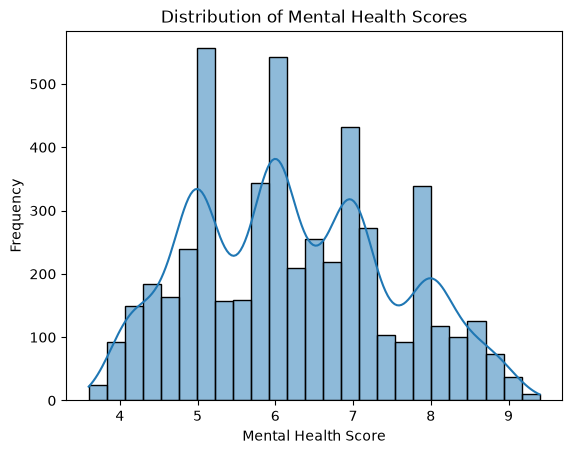

In [10]:
# distribution of target columns
sns.histplot(df['Mental_Health_Score'], kde=True)
plt.title('Distribution of Mental Health Scores')
plt.xlabel('Mental Health Score')
plt.ylabel('Frequency')
plt.show()

In [11]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score'],
      dtype='str')

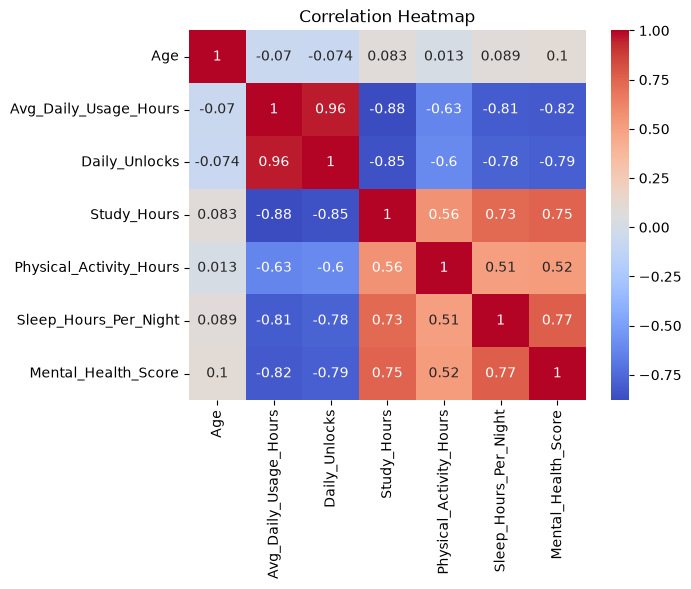

In [12]:
# correlation -> heatmap/              ---method 1
sns.heatmap(df[['Age',
        'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
        'Mental_Health_Score']].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

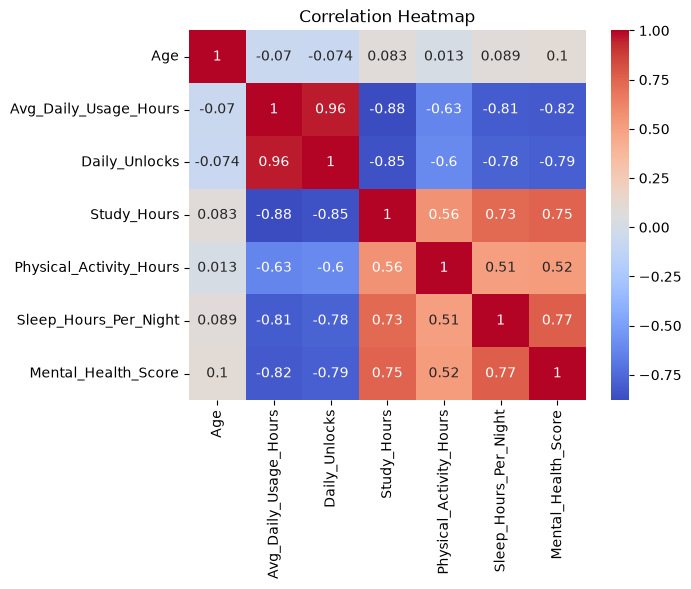

In [13]:
# correlation -> heatmap/              ---method 2
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [14]:
df['Stress_Level'].unique()

<ArrowStringArray>
['Medium', 'Low', 'Very High', 'High']
Length: 4, dtype: str

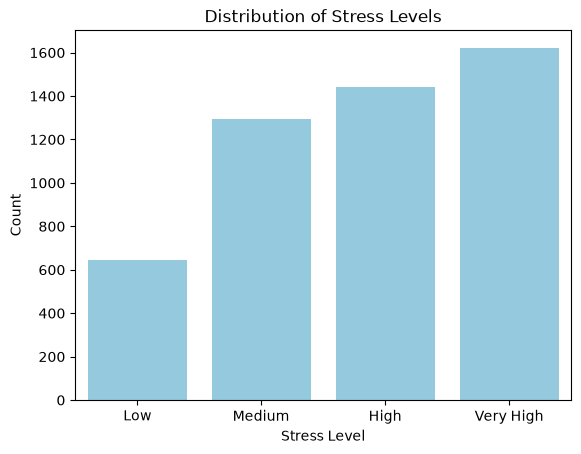

In [15]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.countplot(data=df, x='Stress_Level', order=order , color='skyblue')
plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()

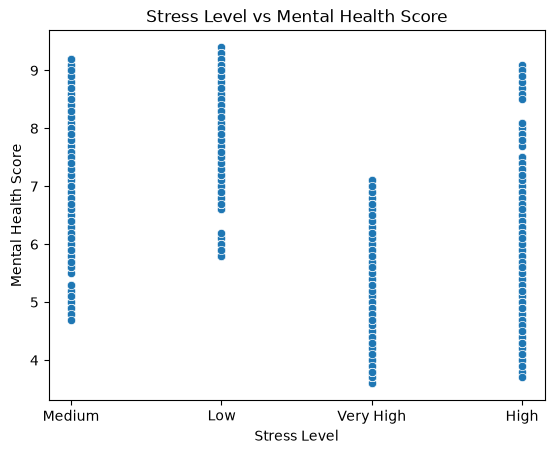

In [16]:
#  Stress Level vs mental Level health score
sns.scatterplot(x='Stress_Level', y='Mental_Health_Score', data=df)
plt.title('Stress Level vs Mental Health Score')
plt.xlabel('Stress Level')
plt.ylabel('Mental Health Score')
plt.show()

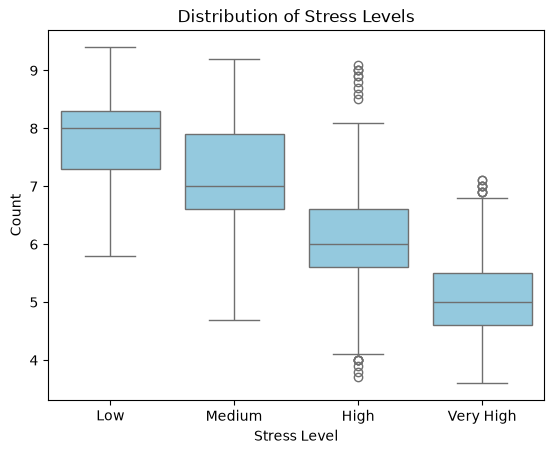

In [17]:
order = ['Low', 'Medium', 'High', 'Very High']
sns.boxplot(x='Stress_Level', y='Mental_Health_Score', data=df, order=order , color='skyblue')
plt.title('Distribution of Stress Levels')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()

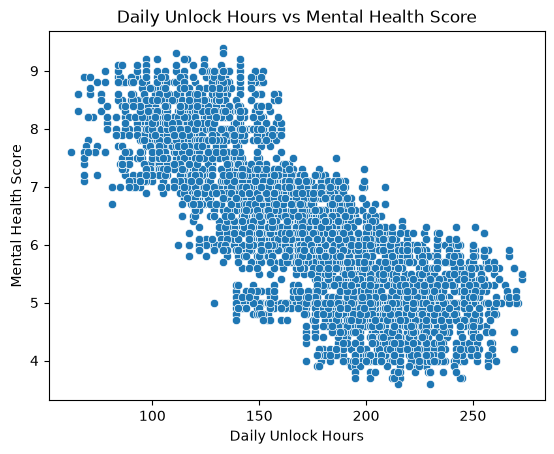

In [18]:
# daily Unlocked Hour vs Mental Health Score
sns.scatterplot(x='Daily_Unlocks', y='Mental_Health_Score', data=df)
plt.title('Daily Unlock Hours vs Mental Health Score')
plt.xlabel('Daily Unlock Hours')
plt.ylabel('Mental Health Score')
plt.show()

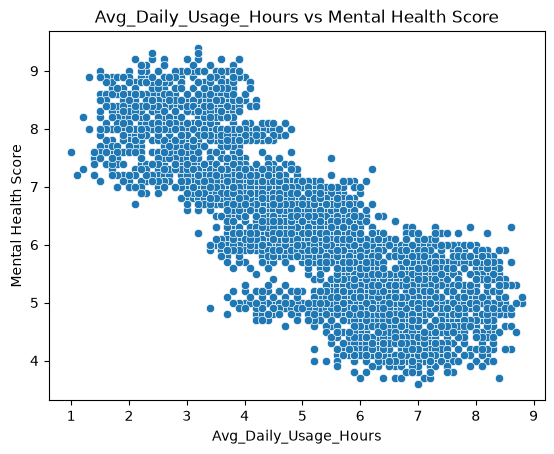

In [19]:
# daily Uses Hour vs Mental Health Score
sns.scatterplot(x='Avg_Daily_Usage_Hours', y='Mental_Health_Score', data=df)
plt.title('Avg_Daily_Usage_Hours vs Mental Health Score')
plt.xlabel('Avg_Daily_Usage_Hours')
plt.ylabel('Mental Health Score')
plt.show()

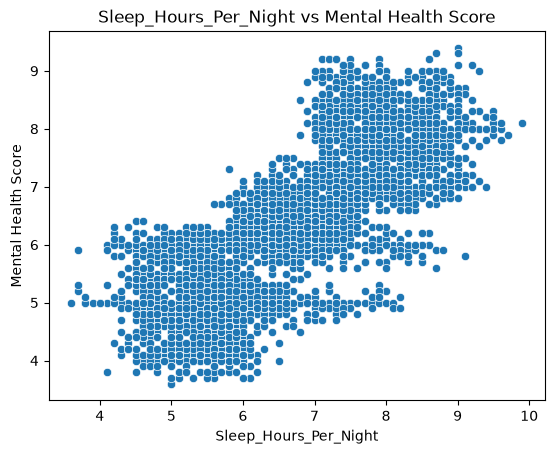

In [20]:
# daily Sleeped Hour per night vs Mental Health Score
sns.scatterplot(x='Sleep_Hours_Per_Night', y='Mental_Health_Score', data=df)
plt.title('Sleep_Hours_Per_Night vs Mental Health Score')
plt.xlabel('Sleep_Hours_Per_Night')
plt.ylabel('Mental Health Score')
plt.show()

In [21]:
plathform_counts=df['Most_Used_Platform'].value_counts()
plathform_counts

Most_Used_Platform
Instagram    1130
TikTok        918
Facebook      719
LinkedIn      523
YouTube       491
Twitter       462
Snapchat      420
WhatsApp      175
LINE           50
VKontakte      40
KakaoTalk      36
WeChat         36
Name: count, dtype: int64

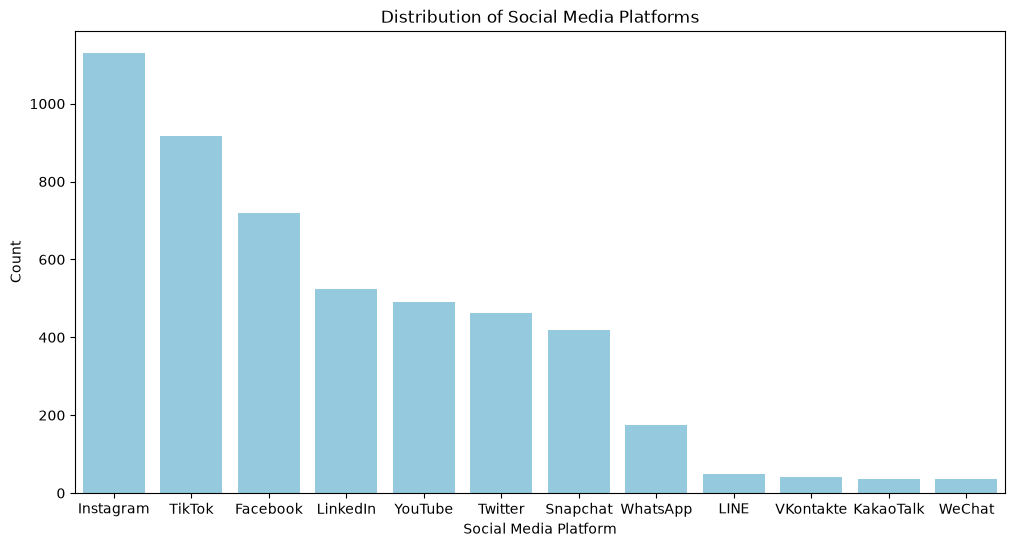

In [22]:
# Most used plathforms
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Most_Used_Platform', order = df['Most_Used_Platform'].value_counts().index , color='skyblue')
plt.title('Distribution of Social Media Platforms')
plt.xlabel('Social Media Platform')
plt.ylabel('Count')
plt.show()

# Checking Outliers

In [23]:
num_features = df.select_dtypes(include='number')  # int64 ya float64
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1
outliers = ((num_features < (Q1 - 1.5 * IQR)) | (num_features > (Q3 + 1.5 * IQR)))  # lower bond and upper bond
outliers_count = outliers.sum()
print(f"Number of outliers: {outliers_count}")

Number of outliers: Age                         0
Avg_Daily_Usage_Hours       0
Daily_Unlocks               0
Study_Hours                 2
Physical_Activity_Hours    22
Sleep_Hours_Per_Night       0
Mental_Health_Score         0
dtype: int64


# DATA Cleaning

In [24]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [25]:
# 1 - to drop duplicate
df=df.drop_duplicates()

# 2 - converting negative  or unrealistics value to realistic value   by using  Clip
df['Physical_Activity_Hours'] = df['Physical_Activity_Hours'].clip(lower=0)
df


,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,18,Female,Other,High School,YouTube,Education,1.9,89,6.1,2.2,7.9,Low,7.9
4996,18,Female,Other,High School,YouTube,Education,6.6,216,2.3,1.8,6.0,Very High,4.7
4997,19,Female,India,Undergraduate,LinkedIn,Education,3.8,151,5.4,1.4,7.5,Medium,7.0
4998,18,Male,Other,High School,Instagram,Entertainment,3.8,119,4.0,1.5,6.4,Medium,6.7


In [26]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


## Chicking Skewness of the data

In [27]:
num_col = df.select_dtypes(include='number')
num_col.skew()
# near to 0 -> Centralize
# negative -> left skewed
# positive -> right skewed

Age                        0.155008
Avg_Daily_Usage_Hours      0.005575
Daily_Unlocks              0.002309
Study_Hours                0.436125
Physical_Activity_Hours    0.053288
Sleep_Hours_Per_Night      0.123919
Mental_Health_Score        0.207086
dtype: float64

## Feature Engineering

In [28]:
df['Country'].value_counts().index[:20].tolist()

['Other',
 'India',
 'USA',
 'Canada',
 'Australia',
 'UK',
 'Germany',
 'Mexico',
 'Turkey',
 'France',
 'Spain',
 'Ireland',
 'Japan',
 'Denmark',
 'Switzerland',
 'Nepal',
 'Italy',
 'Russia',
 'Sri Lanka',
 'Maldives']

In [29]:
top_countries = df['Country'].value_counts().index[:10].tolist()

In [30]:
def group_countries(country):
    if country in top_countries:
        return country
    else:
        return 'Other'

In [31]:
df['Grouped_Country'] = df['Country'].apply(group_countries)
df['Grouped_Country'].value_counts()

Grouped_Country
Other        3231
India         389
USA           354
Canada        230
Australia     198
UK            185
Germany       136
Mexico         94
Turkey         94
France         87
Name: count, dtype: int64

## Encoding of Categorical Columns

In [32]:
df.columns

Index(['Age', 'Gender', 'Country', 'Academic_Level', 'Most_Used_Platform',
       'Purpose_Of_Use', 'Avg_Daily_Usage_Hours', 'Daily_Unlocks',
       'Study_Hours', 'Physical_Activity_Hours', 'Sleep_Hours_Per_Night',
       'Stress_Level', 'Mental_Health_Score', 'Grouped_Country'],
      dtype='str')

In [33]:
from sklearn.model_selection import train_test_split
skwewd_col = ['Study_Hours']

other_numeric_cols = [
    "Age",
    "Avg_Daily_Usage_Hours",
    "Daily_Unlocks",
    "Physical_Activity_Hours",
    "Sleep_Hours_Per_Night"
]

ordinal_col = ['Stress_Level']

normal_col = [
    "Gender",
    "Academic_Level",
    "Most_Used_Platform",
    "Purpose_Of_Use",
    "Grouped_Country"
]

feature_col = skwewd_col + other_numeric_cols + ordinal_col + normal_col

X = df[feature_col]
y = df['Mental_Health_Score']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# PreProcessing Using Columns Transformation

In [34]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Skew Feature
skew_pipeline = Pipeline(
    steps=[
        ("log_transform", FunctionTransformer(np.log1p)),
        ("scaler", StandardScaler())
    ]
)


# Numeric Feature
plain_Numeric_pipeline = Pipeline(
    steps=[
        ("scaler", StandardScaler())
    ]
)


# Ordinal Feature
ordinal_pipeline = Pipeline(
    steps=[
        ("ordinal_encoder", OrdinalEncoder(categories=[['Low', 'Medium', 'High', 'Very High']])),
    ]
)


# Normal Feature
normal_pipeline = Pipeline(
    steps=[
        ("one_hot_encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(transformers=[     # konsi pipeline, konsa feature
    ("skew_pipeline", skew_pipeline, skwewd_col),
    ("plain_Numeric_pipeline", plain_Numeric_pipeline, other_numeric_cols),
    ("ordinal_pipeline", ordinal_pipeline, ordinal_col),
    ("normal_pipeline", normal_pipeline, normal_col)
])

# Building Pipeline

## BaseLine: Linear Regression

In [35]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

lr_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

lr_pipeline.fit(X_train, y_train)
lr_pridict = lr_pipeline.predict(X_test)
lr_pres_train = lr_pipeline.predict(X_train)

lr_mse_testing = mean_squared_error(y_test, lr_pridict)
lr_mae_testing = mean_absolute_error(y_test, lr_pridict)
lr_r2_testing = r2_score(y_test, lr_pridict)
lr_mae = mean_absolute_error(y_test, lr_pridict)
lr_r2 = r2_score(y_test, lr_pridict)
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pridict))

lr_mse_training = mean_squared_error(y_train, lr_pres_train)
lr_mae_training = mean_absolute_error(y_train, lr_pres_train)
lr_r2_training = r2_score(y_train, lr_pres_train)

print(f"Linear Regression Metrics:" )
print(f"Testing MSE: {lr_mse_testing}")
print(f"Testing MAE: {lr_mae_testing}")
print(f"Testing R2: {lr_r2_testing}")
print(f"Training MSE: {lr_mse_training}")
print(f"Training MAE: {lr_mae_training}")
print(f"Training R2: {lr_r2_training}")

Linear Regression Metrics:
Testing MSE: 0.45701905273487986
Testing MAE: 0.5361775634720182
Testing R2: 0.7397944617433021
Training MSE: 0.4367848338582865
Training MAE: 0.5189846926901905
Training R2: 0.7236771199387539


## Random Forest

In [36]:
from sklearn.ensemble import RandomForestRegressor
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(random_state=42))
    ]
)

rf_pipeline.fit(X_train, y_train)
rf_pridict = rf_pipeline.predict(X_test)
rf_pres_train = rf_pipeline.predict(X_train)

rf_mse_testing = mean_squared_error(y_test, rf_pridict)
rf_mae_testing = mean_absolute_error(y_test, rf_pridict)
rf_r2_testing = r2_score(y_test, rf_pridict)
rf_mae = mean_absolute_error(y_test, rf_pridict)
rf_r2 = r2_score(y_test, rf_pridict)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pridict))


rf_mse_training = mean_squared_error(y_train, rf_pres_train)
rf_mae_training = mean_absolute_error(y_train, rf_pres_train)
rf_r2_training = r2_score(y_train, rf_pres_train)

print(f"Random Forest Metrics:" )
print(f"Testing MSE: {rf_mse_testing}")
print(f"Testing MAE: {rf_mae_testing}")
print(f"Testing R2: {rf_r2_testing}")
print(f"Training MSE: {rf_mse_training}")
print(f"Training MAE: {rf_mae_training}")
print(f"Training R2: {rf_r2_training}")


Random Forest Metrics:
Testing MSE: 0.214248595535
Testing MAE: 0.34650236666666673
Testing R2: 0.8780167461546369
Training MSE: 0.03018049605488855
Training MAE: 0.12631875357347067
Training R2: 0.9809069341581819


## Hyperparameter Tuning the Random Forest

In [37]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'model__n_estimators'       : [100,200,300],
    'model__max_depth'         : [5,10,15],
    'model__min_samples_split' : [2,5,10],
    'model__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

random_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__max_depth': [5, 10, ...], 'model__min_samples_leaf': [1, 2, ...], 'model__min_samples_split': [2, 5, ...], 'model__n_estimators': [100, 200, ...]}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",15
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'r2'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"random_state random_state: int, RandomState instance or None, default=NonePseudo random number generator state used for random uniform samplingfrom lists of possible values instead of scipy.stats distributions.Pass an int for reproducible output across multiplefunction calls.See :term:`Glossary <random_state>`.",42
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV

In [38]:
random_search.best_params_

{'model__n_estimators': 200,
 'model__min_samples_split': 5,
 'model__min_samples_leaf': 2,
 'model__max_depth': 15}

In [39]:
rf_best_pipeline = random_search.best_estimator_
rf_best_preds    = rf_best_pipeline.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.8652257547733472
MAE Score for random forest after hyperparameter tuning 0.36866505007865863


# Model Evalution

In [40]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_pridict))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pridict))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)


# Create a DataFrame to consolidate results
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

print(results)


                     Model        R2  Training R2       MAE      RMSE
0        Linear Regression  0.739794     0.723677  0.536178  0.676032
1  Random Forest (default)  0.878017     0.980907  0.346502  0.462870
2    Random Forest (tuned)  0.865226     0.954656  0.368665  0.486533


# Saving the model

In [41]:
import joblib
joblib.dump(rf_pipeline, 'Mental_Health_Model.pkl')

['Mental_Health_Model.pkl']

In [42]:
df.columns.to_list()

['Age',
 'Gender',
 'Country',
 'Academic_Level',
 'Most_Used_Platform',
 'Purpose_Of_Use',
 'Avg_Daily_Usage_Hours',
 'Daily_Unlocks',
 'Study_Hours',
 'Physical_Activity_Hours',
 'Sleep_Hours_Per_Night',
 'Stress_Level',
 'Mental_Health_Score',
 'Grouped_Country']